# Avaliação de resultados
Aqui temos como objetivo ver como o modelo se comporta no conjunto de testes

## Import de frameworks

In [36]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report, roc_auc_score

## Import de modelo e avaliação de resultados

In [2]:
with open("output_files/lgbm_classifier_multiclass.pkl", "rb") as arquivo:
    modelo_carregado = pickle.load(arquivo)

In [17]:
dataset_test = pd.read_csv('datasets/dataset_test.csv')

In [18]:
for col in dataset_train.select_dtypes(include=['object', 'string']).columns:
    dataset_test[col] = dataset_test[col].astype('category')
X=dataset_test.drop(columns=['income'])
y=dataset_test['income']

In [19]:
dataset_test['predictions'] = modelo_carregado.predict(X)
dataset_test['predictions'] = dataset_test['predictions'].astype('category')
dataset_test

,region,income,year,population,overall_score,data_use_score,data_services_score,data_products_score,data_sources_score,data_infrastructure_score,predictions
0,Europe & Central Asia,High income,2023,5946952,95.255833,100.0,98.466667,90.71250,87.100,100.0,High income
1,Europe & Central Asia,High income,2023,5584264,95.115417,100.0,96.433333,90.96875,88.175,100.0,High income
2,Europe & Central Asia,High income,2023,36685849,94.653750,100.0,97.300000,84.54375,91.425,100.0,High income
3,Europe & Central Asia,High income,2023,10536632,94.410000,100.0,96.000000,90.57500,85.475,100.0,High income
4,Europe & Central Asia,High income,2023,48373336,94.325000,100.0,91.200000,92.62500,87.800,100.0,High income
...,...,...,...,...,...,...,...,...,...,...,...
859,Latin America & Caribbean,High income,2020,40350,NaN,30.0,NaN,16.46875,NaN,NaN,High income
860,Latin America & Caribbean,High income,2020,32553,NaN,40.0,NaN,13.91875,NaN,NaN,High income
861,Latin America & Caribbean,High income,2020,44276,NaN,30.0,NaN,22.19375,NaN,NaN,High income
862,East Asia & Pacific,Upper middle income,2020,11069,NaN,50.0,NaN,54.77500,NaN,5.0,Upper middle income


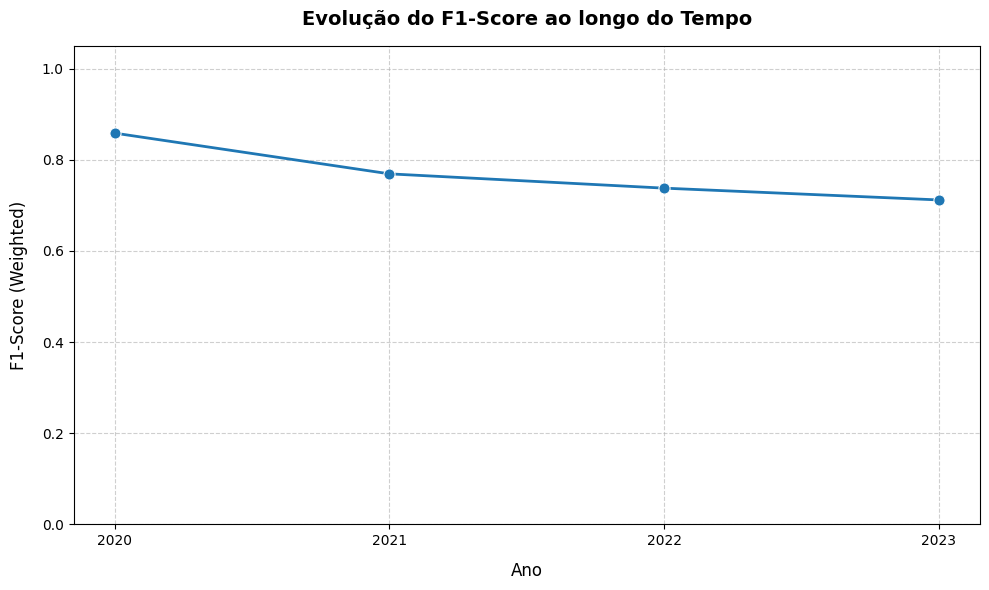

In [42]:
# 1. Defina o nome da sua coluna de tempo
coluna_tempo = 'year' # Substitua pelo nome real da coluna no seu dataset_full

anos = []
f1_scores = []

# 2. Agrupa os dados e calcula o F1-score para cada período
# O groupby vai separar o dataset_test em "mini datasets", um para cada ano
for ano, grupo in dataset_test.groupby(coluna_tempo):
    y_real = grupo['income']
    y_pred = grupo['predictions']
    
    # Usando average='weighted' porque o seu modelo foi treinado como multiclass
    score = f1_score(y_real, y_pred, average='weighted')
    
    anos.append(ano)
    f1_scores.append(score)

# 3. Construção do Gráfico
plt.figure(figsize=(10, 6))

# Cria a linha com os marcadores (bolinhas) em cada ponto
sns.lineplot(x=anos, y=f1_scores, marker='o', color='#1f77b4', linewidth=2, markersize=8)

# 4. Estética e Textos
plt.title('Evolução do F1-Score ao longo do Tempo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ano', fontsize=12, labelpad=10)
plt.ylabel('F1-Score (Weighted)', fontsize=12, labelpad=10)

# Garante que todos os anos fiquem visíveis no eixo X sem números "quebrados"
plt.xticks(anos) 

# Coloca o limite do eixo Y de 0 a 1 (já que o F1-Score máximo é 1.0)
# Se os seus scores estiverem todos muito altos (ex: entre 0.8 e 0.9), 
# você pode mudar para plt.ylim(0.5, 1.0) para dar um "zoom" na linha.
plt.ylim(0, 1.05) 

# Adiciona uma grade sutil ao fundo para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Mostra o gráfico
plt.tight_layout()
plt.savefig('images/evolucao_f1_score.png')
plt.show()

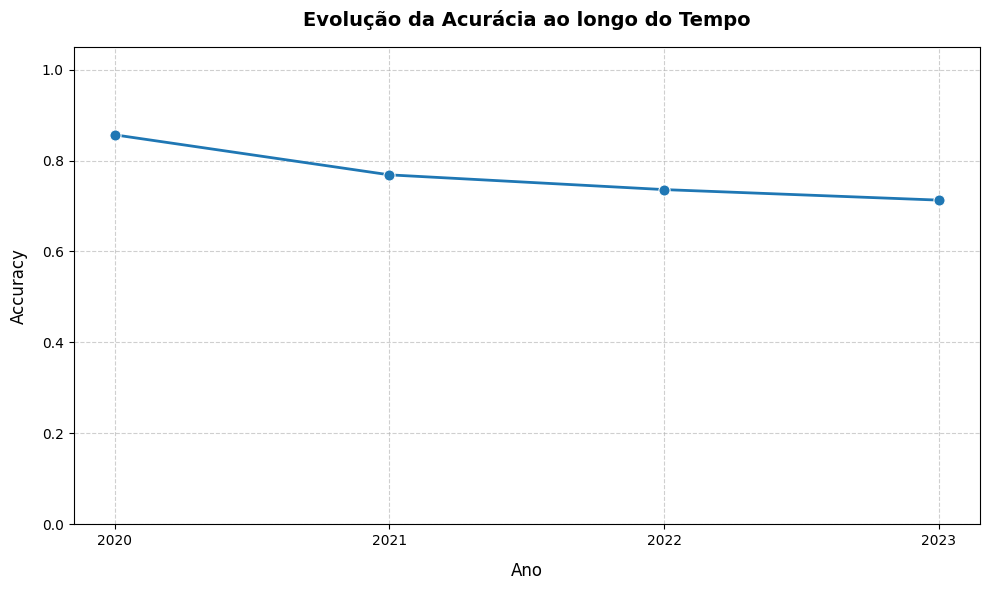

In [44]:
# 1. Defina o nome da sua coluna de tempo
coluna_tempo = 'year' # Substitua pelo nome real da coluna no seu dataset_full

anos = []
f1_scores = []

# 2. Agrupa os dados e calcula o F1-score para cada período
# O groupby vai separar o dataset_test em "mini datasets", um para cada ano
for ano, grupo in dataset_test.groupby(coluna_tempo):
    y_real = grupo['income']
    y_pred = grupo['predictions']
    
    # Usando average='weighted' porque o seu modelo foi treinado como multiclass
    score = accuracy_score(y_real, y_pred)
    
    anos.append(ano)
    f1_scores.append(score)

# 3. Construção do Gráfico
plt.figure(figsize=(10, 6))

# Cria a linha com os marcadores (bolinhas) em cada ponto
sns.lineplot(x=anos, y=f1_scores, marker='o', color='#1f77b4', linewidth=2, markersize=8)

# 4. Estética e Textos
plt.title('Evolução da Acurácia ao longo do Tempo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ano', fontsize=12, labelpad=10)
plt.ylabel('Accuracy', fontsize=12, labelpad=10)

# Garante que todos os anos fiquem visíveis no eixo X sem números "quebrados"
plt.xticks(anos) 

# Coloca o limite do eixo Y de 0 a 1 (já que o F1-Score máximo é 1.0)
# Se os seus scores estiverem todos muito altos (ex: entre 0.8 e 0.9), 
# você pode mudar para plt.ylim(0.5, 1.0) para dar um "zoom" na linha.
plt.ylim(0, 1.05) 

# Adiciona uma grade sutil ao fundo para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Mostra o gráfico
plt.tight_layout()
plt.savefig('images/evolucao_acuracia.png')
plt.show()

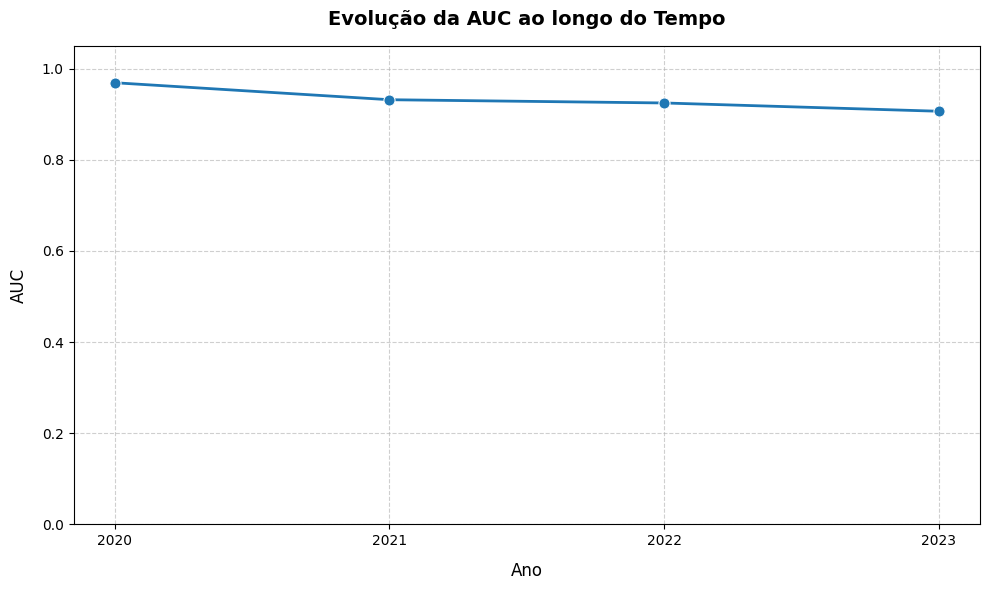

In [45]:
# 1. Defina o nome da sua coluna de tempo
coluna_tempo = 'year' # Substitua pelo nome real da coluna no seu dataset_full

anos = []
roc_scores = []

# Vamos iterar sobre o dataset novamente
for ano, grupo in dataset_test.groupby(coluna_tempo):
    y_real = grupo['income']
    
    # 1. Separamos o X apenas para este grupo (ano)
    # Assumindo que a sua variável 'X' original com as colunas certas ainda está na memória
    X_grupo = grupo[X.columns] 
    
    # 2. Geramos as PROBABILIDADES em vez da classe final
    y_proba = modelo_carregado.predict_proba(X_grupo)
    
    # 3. Calculamos o score com o parâmetro multi_class='ovr'
    score = roc_auc_score(y_real, y_proba, multi_class='ovr', average='weighted')
    
    anos.append(ano)
    roc_scores.append(score)

# 3. Construção do Gráfico
plt.figure(figsize=(10, 6))

# Cria a linha com os marcadores (bolinhas) em cada ponto
sns.lineplot(x=anos, y=roc_scores, marker='o', color='#1f77b4', linewidth=2, markersize=8)

# 4. Estética e Textos
plt.title('Evolução da AUC ao longo do Tempo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ano', fontsize=12, labelpad=10)
plt.ylabel('AUC', fontsize=12, labelpad=10)

# Garante que todos os anos fiquem visíveis no eixo X sem números "quebrados"
plt.xticks(anos) 

# Coloca o limite do eixo Y de 0 a 1 (já que o F1-Score máximo é 1.0)
# Se os seus scores estiverem todos muito altos (ex: entre 0.8 e 0.9), 
# você pode mudar para plt.ylim(0.5, 1.0) para dar um "zoom" na linha.
plt.ylim(0, 1.05) 

# Adiciona uma grade sutil ao fundo para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Mostra o gráfico
plt.tight_layout()
plt.savefig('images/evolucao_auc.png')
plt.show()

In [46]:
print(classification_report(y, dataset_test['predictions']))

                     precision    recall  f1-score   support

        High income       0.89      0.85      0.87       340
         Low income       0.73      0.80      0.76       104
Lower middle income       0.71      0.65      0.68       204
Upper middle income       0.67      0.74      0.70       216

           accuracy                           0.77       864
          macro avg       0.75      0.76      0.75       864
       weighted avg       0.77      0.77      0.77       864



In [26]:
df_importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importancia': modelo_carregado.feature_importances_
})

# 2. Ordena da mais importante para a menos importante (ordem decrescente)
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False).reset_index(drop=True)

# 3. Calcula o percentual que cada uma representa (e já arredonda para 2 casas decimais)
df_importancias['Percentual (%)'] = (df_importancias['Importancia'] / df_importancias['Importancia'].sum() * 100).round(2)

# 4. Calcula o percentual ACUMULADO usando a função mágica do pandas: cumsum()
df_importancias['Percentual Acumulado (%)'] = df_importancias['Percentual (%)'].cumsum().round(2)

df_importancias

,Feature,Importancia,Percentual (%),Percentual Acumulado (%)
0,population,12873,45.65,45.65
1,data_products_score,8019,28.44,74.09
2,data_sources_score,1761,6.24,80.33
3,data_use_score,1660,5.89,86.22
4,year,1131,4.01,90.23
5,region,1011,3.59,93.82
6,data_infrastructure_score,884,3.13,96.95
7,overall_score,442,1.57,98.52
8,data_services_score,418,1.48,100.00


In [47]:
df_importancias.to_csv('output_files/importancias_modelo.csv', index=False)

## Conclusão

Podemos observar, após todo o trabalho do optuna, a eficácia de uma boa tunagem de modelos. Dado que estamos trabalhando principalmente com um dataset com dados que sabemos que tem uma queda temporal a partir do ano de 2020, o modelo mostrou uma ótima capacidade discriminatória ao longo do tempo. Talvez uma evolução seja testar esse mesmo processo utilizando uma separação de dados de maneira simplificada (70/30 ou 80/20). Apesar, de normalmente, isso não seja feito na realidade.

De todo modo, a métrica principal, que era o f1-score, se manteve alta no tempo (0.77). Fazendo com que tivéssemos um bom modelo acima de tudo.